<a href="https://colab.research.google.com/github/sofiahuang2225-prog/python-DM-group-k/blob/main/ML_RF_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###1. Setup and data loading

In [19]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install flaml
from flaml import AutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 6.8 MB/s eta 0:00:00


In [20]:
df=pd.read_csv('final_HR-Employee-Attrition.csv')

In [21]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Attrition                          1470 non-null   bool   
 1   DistanceFromHome                   1470 non-null   int64  
 2   Education                          1470 non-null   int64  
 3   EnvironmentSatisfaction            1470 non-null   int64  
 4   JobInvolvement                     1470 non-null   int64  
 5   JobSatisfaction                    1470 non-null   int64  
 6   MonthlyIncome                      1470 non-null   int64  
 7   NumCompaniesWorked                 1470 non-null   int64  
 8   OverTime                           1470 non-null   bool   
 9   PerformanceRating                  1470 non-null   int64  
 10  RelationshipSatisfaction           1470 non-null   int64  
 11  StockOptionLevel                   1470 non-null   int64

,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,OverTime,PerformanceRating,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,True,1,2,2,3,4,5993,8,True,3,...,False,False,False,False,False,False,True,False,False,True
1,False,8,1,3,2,2,5130,1,False,4,...,False,False,False,False,False,True,False,False,True,False
2,True,2,2,4,2,3,2090,6,True,3,...,False,True,False,False,False,False,False,False,False,True
3,False,3,4,4,3,3,2909,1,True,3,...,False,False,False,False,False,True,False,False,True,False
4,False,2,1,1,3,2,3468,9,False,3,...,False,True,False,False,False,False,False,False,True,False
5,False,2,2,4,3,4,3068,0,False,3,...,False,True,False,False,False,False,False,False,False,True
6,False,3,3,3,4,1,2670,4,True,4,...,False,True,False,False,False,False,False,False,True,False
7,False,24,1,4,3,3,2693,1,False,4,...,False,True,False,False,False,False,False,False,False,False
8,False,23,3,4,2,3,9526,0,False,4,...,False,False,False,True,False,False,False,False,False,True
9,False,27,3,3,3,3,5237,6,False,3,...,False,False,False,False,False,False,False,False,True,False


In [5]:
df.describe()

,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TrainingTimesLastYear,WorkLifeBalance,YearsInCurrentRole,PromotionStagnation,IncomePerYearExp,CompanyTenureRatio
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,9.192517,2.912925,2.721769,2.729932,2.728571,6502.931293,2.693197,3.153741,2.712245,0.793878,2.799320,2.761224,4.229252,0.236458,587.575385,0.581830
std,8.106864,1.024165,1.093082,0.711561,1.102846,4707.956783,2.498009,0.360824,1.081209,0.852077,1.289271,0.706476,3.623137,0.269358,284.650784,0.284476
min,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,3.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,95.285714,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2911.000000,1.000000,3.000000,2.000000,0.000000,2.000000,2.000000,2.000000,0.000000,374.232143,0.368421
50%,7.000000,3.000000,3.000000,3.000000,3.000000,4919.000000,2.000000,3.000000,3.000000,1.000000,3.000000,3.000000,3.000000,0.142857,549.220648,0.636364
75%,14.000000,4.000000,4.000000,3.000000,4.000000,8379.000000,4.000000,3.000000,4.000000,1.000000,3.000000,3.000000,7.000000,0.428571,738.303846,0.833333
max,29.000000,5.000000,4.000000,4.000000,4.000000,19999.000000,9.000000,4.000000,4.000000,3.000000,6.000000,4.000000,18.000000,0.916667,1904.000000,0.975610


### 1.1 設定員工特徵值資料的預設值X_default

In [22]:
#設定員工特徵值資料的預設值X_default
X_default = df.drop(columns=['Attrition'])[:1]
bool_cols = df.select_dtypes(include=['bool']).columns
#將X_default的非Boolen欄位的值改為原本資料的中位數
for col in X_default.columns:
    if col not in bool_cols:
        X_default[col] = int(df[col].median())
    elif col in bool_cols:
        counts = df[col].value_counts()
        majority_value = counts.idxmax()
        X_default[col] = df[col].mode()[0]
X_default[X_default.select_dtypes(include=['bool']).columns] = X_default[X_default.select_dtypes(include=['bool']).columns].astype(int)
print(f'將員工預設特徵值資料輸出為檔案...')
X_default.to_csv('X_default.csv', index=False)

將員工預設特徵值資料輸出為檔案...


### 2. Training Model with FLAML

###2.1 Find best training/Test data split ratio

In [23]:
# 1.確保目標變數 (Y) 轉換為數值 0 和 1 (True->1, False->0)
df['Attrition'] = df['Attrition'].astype(int)

#2. 將布林形態特徵也都轉為(0/1)
# 假設 df 中有數個布林欄位
bool_cols = df.select_dtypes(include=['bool']).columns
# 直接將這些欄位轉成整數 0/1
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Standardisation
scale_standard = StandardScaler()
X = scale_standard.fit_transform(X)


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



--- 搭配不同資料分割比例，優化 Logistic Regression ---


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


> 測試集比例 10%: Train(CV) F1 = 0.5122, Test F1 = 0.4722


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


...

> 測試集比例 60%: Train(CV) F1 = 0.4879, Test F1 = 0.4766


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


> 測試集比例 70%: Train(CV) F1 = 0.5117, Test F1 = 0.4696


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


> 測試集比例 80%: Train(CV) F1 = 0.5481, Test F1 = 0.4618
> 測試集比例 90%: Train(CV) F1 = 0.4228, Test F1 = 0.4681


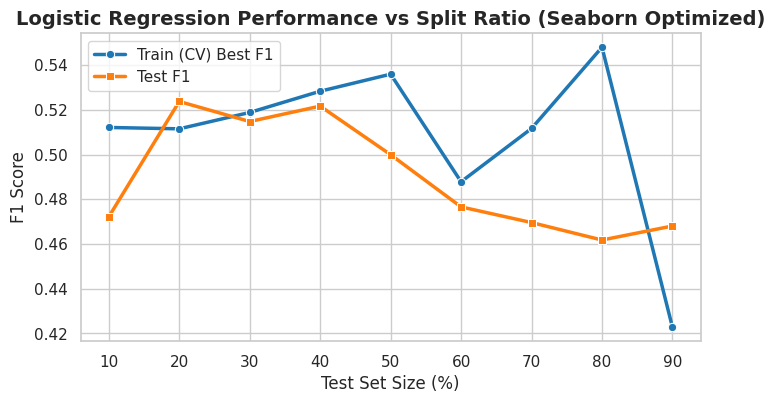

In [31]:
# ==========================================
# 步驟 A：用 FLAML 自動優化 Logistic Regression (不同分割比例實驗)
# ==========================================
print("\n--- 搭配不同資料分割比例，優化 Logistic Regression ---")

import copy
import seaborn as sns
sns.set_theme(style="whitegrid")

automl_lr = AutoML()
settings_lr = {
    "time_budget": 60,
    "metric": 'f1',
    "task": 'classification',
    "estimator_list": ['lrl1', 'lrl2'],
    "custom_hp": {
        "lrl1": {"class_weight": {"domain": "balanced"}},
        "lrl2": {"class_weight": {"domain": "balanced"}}
    },
    "seed": 42,
    "verbose": 0
}

ratio_values = [i for i in range(10, 100, 10)]
train_f1_scores_lr = []
test_f1_scores_lr = []

automl_lr_best = None
best_overall_f1_lr = -1

for i in ratio_values:
    test_size_ratio = i / 100
    X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(
        X, y, test_size=test_size_ratio, random_state=42, stratify=y
    )

    automl_lr.fit(X_train=X_train_loop, y_train=y_train_loop, **settings_lr)

    best_train_f1 = 1 - automl_lr.best_loss
    train_f1_scores_lr.append(best_train_f1)

    y_pred_test = automl_lr.predict(X_test_loop)
    current_test_f1 = f1_score(y_test_loop, y_pred_test)
    test_f1_scores_lr.append(current_test_f1)

    if current_test_f1 > best_overall_f1_lr:
        best_overall_f1_lr = current_test_f1
        automl_lr_best = copy.deepcopy(automl_lr)
        best_ratio_lr = i/100

    print(f"> 測試集比例 {i}%: Train(CV) F1 = {best_train_f1:.4f}, Test F1 = {current_test_f1:.4f}")

# 美化繪圖
plt.figure(figsize=(8, 4))
sns.lineplot(x=ratio_values, y=train_f1_scores_lr, marker='o', label='Train (CV) Best F1', color='#1f77b4', linewidth=2.5)
sns.lineplot(x=ratio_values, y=test_f1_scores_lr, marker='s', label='Test F1', color='#ff7f0e', linewidth=2.5)

plt.xlabel('Test Set Size (%)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Logistic Regression Performance vs Split Ratio (Seaborn Optimized)', fontsize=14, fontweight='bold')
plt.legend(frameon=True, facecolor='white')
plt.show()


--- 搭配不同資料分割比例，優化 Random Forest ---
> 測試集比例 10%: Train(CV) F1 = 0.5277, Test F1 = 0.4000
> 測試集比例 20%: Train(CV) F1 = 0.5297, Test F1 = 0.4902
> 測試集比例 30%: Train(CV) F1 = 0.5531, Test F1 = 0.4533
> 測試集比例 40%: Train(CV) F1 = 0.5247, Test F1 = 0.4976
> 測試集比例 50%: Train(CV) F1 = 0.5304, Test F1 = 0.4419
> 測試集比例 60%: Train(CV) F1 = 0.4982, Test F1 = 0.4759
> 測試集比例 70%: Train(CV) F1 = 0.4962, Test F1 = 0.4490
> 測試集比例 80%: Train(CV) F1 = 0.4915, Test F1 = 0.4127
> 測試集比例 90%: Train(CV) F1 = 0.4203, Test F1 = 0.3790


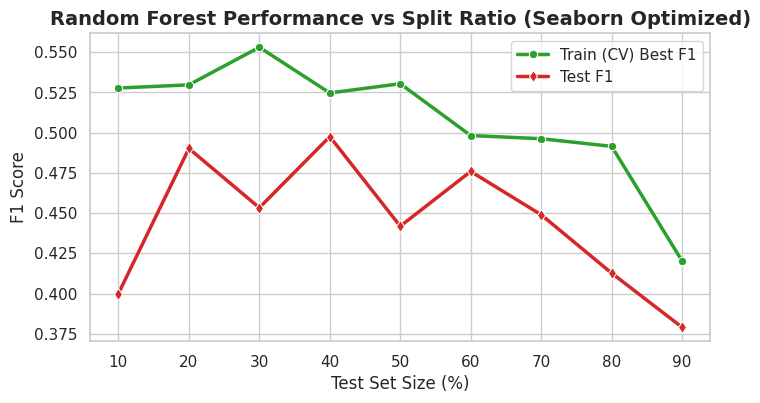

In [32]:
# ==========================================
# 步驟 B：用 FLAML 自動優化 Random Forest (不同分割比例實驗)
# ==========================================
print("\n--- 搭配不同資料分割比例，優化 Random Forest ---")

import copy
import seaborn as sns
sns.set_theme(style="whitegrid")

automl_rf = AutoML()
settings_rf = {
    "time_budget": 120,
    "metric": 'f1',
    "task": 'classification',
    "estimator_list": ['rf'],
    "custom_hp": {
        "rf": {
            "class_weight": {"domain": "balanced"}
        }
    },
    "seed":42,
    "verbose": 0
}

ratio_values = [i for i in range(10, 100, 10)]
train_f1_scores = []
test_f1_scores = []

automl_rf_best = None
best_overall_f1 = -1

for i in ratio_values:
    test_size_ratio = i / 100
    X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(
        X, y, test_size=test_size_ratio, random_state=42, stratify=y
    )

    automl_rf.fit(X_train=X_train_loop, y_train=y_train_loop, **settings_rf)

    best_train_f1 = 1 - automl_rf.best_loss
    train_f1_scores.append(best_train_f1)

    y_pred_test = automl_rf.predict(X_test_loop)
    current_test_f1 = f1_score(y_test_loop, y_pred_test)
    test_f1_scores.append(current_test_f1)

    if current_test_f1 > best_overall_f1:
        best_overall_f1 = current_test_f1
        automl_rf_best = copy.deepcopy(automl_rf)
        best_ratio_rf = i/100

    print(f"> 測試集比例 {i}%: Train(CV) F1 = {best_train_f1:.4f}, Test F1 = {current_test_f1:.4f}")

# 美化繪圖
plt.figure(figsize=(8, 4))
sns.lineplot(x=ratio_values, y=train_f1_scores, marker='o', label='Train (CV) Best F1', color='#2ca02c', linewidth=2.5)
sns.lineplot(x=ratio_values, y=test_f1_scores, marker='d', label='Test F1', color='#d62728', linewidth=2.5)

plt.xlabel('Test Set Size (%)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Random Forest Performance vs Split Ratio (Seaborn Optimized)', fontsize=14, fontweight='bold')
plt.legend(frameon=True, facecolor='white')
plt.show()

In [33]:
# ==========================================
# 3. 輸出兩者的最佳表現比較
# ==========================================
print("\n=== FLAML 最佳化結果比較 ===")
print(f"Logistic Regression 最佳超參數: {automl_lr_best.best_config}")
print(f"Logistic Regression 在訓練集(驗證)的最佳 F1: {1 - automl_lr_best.best_loss:.4f}")
print(f"Logistic Regression 的測試集(驗證)的最佳F1: {best_overall_f1_lr}")
print(f"Logistic Regression 的最佳資料分拆比例：{best_ratio_lr}")

print(f"\nRandom Forest 最佳超參數: {automl_rf_best.best_config}")
print(f"Random Forest 在訓練集(驗證)的最佳 F1: {1 - automl_rf_best.best_loss:.4f}")
print(f"Random Forest 的測試集(驗證)的最佳F1: {best_overall_f1}")
print(f"Random Forest 的最佳資料分拆比例：{best_ratio_rf}")


=== FLAML 最佳化結果比較 ===
Logistic Regression 最佳超參數: {'C': np.float64(0.1620472422498409), 'class_weight': 'balanced'}
Logistic Regression 在訓練集(驗證)的最佳 F1: 0.5116
Logistic Regression 的測試集(驗證)的最佳F1: 0.5238095238095238
Logistic Regression 的最佳資料分拆比例：0.2

Random Forest 最佳超參數: {'n_estimators': 35, 'max_features': np.float64(0.11696658009254934), 'max_leaves': 23, 'criterion': np.str_('gini'), 'class_weight': 'balanced'}
Random Forest 在訓練集(驗證)的最佳 F1: 0.5247
Random Forest 的測試集(驗證)的最佳F1: 0.4975609756097561
Random Forest 的最佳資料分拆比例：0.4


### 2.2 AutoML with best training/test ratio of dataset

In [34]:
# 1. 切分訓練集與測試集
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #best_ratio_lr
# 2. 初始化 FLAML
automl_lr = AutoML()

# 3. 關鍵設定：透過 custom_hp 固定邏輯斯迴歸的類別權重
settings_lr = {
    "time_budget": 300,            # 自動調參時間（秒）
    "metric": 'f1',               # 優化目標：F1-score
    "task": 'classification',     # 分類任務
    "estimator_list": ['lrl1', 'lrl2'], # 強制只訓練 L1/L2 Logistic Regression

    # 🔥 核心設定：為 Logistic Regression 加入 class_weight='balanced'
    "custom_hp": {
        "lrl1": {
            "class_weight": {
                "domain": "balanced"  # 鎖定 L1 版本的權重為 balanced
            }
        },
        "lrl2": {
            "class_weight": {
                "domain": "balanced"  # 鎖定 L2 版本的權重為 balanced
            }
        }
    },
    "seed": 42,
    "log_file_name": 'hr_logistic_regression_automl.log',
}

# 5. 開始自動化訓練與調參
print("--- 開始執行 Logistic Regression (已設定 Class Weight) 自動優化 ---")
automl_lr.fit(X_train=X_train_lr, y_train=y_train_lr, **settings_lr)

# 6. 檢視最佳結果
print("\n=== 優化完成 ===")
print(f"最佳模型演算法: {automl_lr.best_estimator}")
print(f"最佳超參數組合: {automl_lr.best_config}")
print(f"訓練/驗證集最佳 F1-score: {1 - automl_lr.best_loss:.4f}")

--- 開始執行 Logistic Regression (已設定 Class Weight) 自動優化 ---
[flaml.automl.logger: 05-28 07:12:52] {2375} INFO - task = classification
[flaml.automl.logger: 05-28 07:12:52] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-28 07:12:52] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 05-28 07:12:52] {2606} INFO - List of ML learners in AutoML Run: ['lrl1', 'lrl2']
[flaml.automl.logger: 05-28 07:12:52] {2911} INFO - iteration 0, current learner lrl1


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-28 07:12:53] {3046} INFO - Estimated sufficient time budget=15163s. Estimated necessary time budget=15s.
[flaml.automl.logger: 05-28 07:12:53] {3097} INFO -  at 1.6s,	estimator lrl1's best error=4.9710e-01,	best estimator lrl1's best error=4.9710e-01
[flaml.automl.logger: 05-28 07:12:53] {2911} INFO - iteration 1, current learner lrl2


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-28 07:13:09] {3097} INFO -  at 17.0s,	estimator lrl2's best error=4.9532e-01,	best estimator lrl2's best error=4.9532e-01
[flaml.automl.logger: 05-28 07:13:09] {2911} INFO - iteration 2, current learner lrl1
[flaml.automl.logger: 05-28 07:13:10] {3097} INFO -  at 18.3s,	estimator lrl1's best error=4.9710e-01,	best estimator lrl2's best error=4.9532e-01
[flaml.automl.logger: 05-28 07:13:10] {2911} INFO - iteration 3, current learner lrl1
[flaml.automl.logger: 05-28 07:13:10] {3097} INFO -  at 18.6s,	estimator lrl1's best error=4.9710e-01,	best estimator lrl2's best error=4.9532e-01
[flaml.automl.logger: 05-28 07:13:10] {2911} INFO - iteration 4, current learner lrl1
[flaml.automl.logger: 05-28 07:13:11] {3097} INFO -  at 19.0s,	estimator lrl1's best error=4.9687e-01,	best estimator lrl2's best error=4.9532e-01
[flaml.automl.logger: 05-28 07:13:11] {2911} INFO - iteration 5, current learner lrl1
[flaml.automl.logger: 05-28 07:13:11] {3097} INFO -  at 19.4s,	estim

In [48]:
# 1. 切分訓練集與測試集
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #best_ratio_rf
# 建立 FLAML 實例
automl_rf = AutoML()

# 定義設定
settings_rf = {
    "time_budget": 600,
    "metric": 'f1',            # 1. 考試標準：追求最高的 F1-score
    "task": 'classification',
    "estimator_list": ['rf'],  # 強制隨機森林

    # 2. 強制鎖定底層模型的 class_weight 為 'balanced'
    "custom_hp": {
        "rf": {
            "class_weight": {
                "domain": "balanced"  # 強制固定為 balanced，不讓 FLAML 去隨機嘗試 None
            }
        }
    },
    "seed":42,
    "log_file_name": 'hr_rf_automl.log',
}

# 開始訓練
automl_rf.fit(X_train=X_train_rf, y_train=y_train_rf, **settings_rf)

[flaml.automl.logger: 05-28 09:19:34] {2375} INFO - task = classification
[flaml.automl.logger: 05-28 09:19:34] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-28 09:19:34] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 05-28 09:19:34] {2606} INFO - List of ML learners in AutoML Run: ['rf']
[flaml.automl.logger: 05-28 09:19:34] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 05-28 09:19:35] {3046} INFO - Estimated sufficient time budget=3316s. Estimated necessary time budget=3s.
[flaml.automl.logger: 05-28 09:19:35] {3097} INFO -  at 0.4s,	estimator rf's best error=5.8601e-01,	best estimator rf's best error=5.8601e-01
[flaml.automl.logger: 05-28 09:19:35] {2911} INFO - iteration 1, current learner rf
[flaml.automl.logger: 05-28 09:19:35] {3097} INFO -  at 0.8s,	estimator rf's best error=5.8601e-01,	best estimator rf's best error=5.8601e-01
[flaml.automl.logger: 05-28 09:19:35] {2911} INFO - iteration 2, current learner rf
[flaml.autom

### 3. 測試集性能評估與比較

首先，我們將從 FLAML 獲得的最佳模型中，對測試集進行預測並計算各項性能指標 (Accuracy, Precision, Recall, F1-score, ROC AUC)。


In [49]:
# 函數來計算和打印所有評估指標
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\n--- {model_name} 測試集表現 ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

In [50]:
# 對測試集進行預測
y_pred_lr = automl_lr.predict(X_test_lr)
y_pred_rf = automl_rf.predict(X_test_rf)

# 對測試集進行概率預測 (用於 ROC AUC)
y_pred_proba_lr = automl_lr.predict_proba(X_test_lr)[:, 1]
y_pred_proba_rf = automl_rf.predict_proba(X_test_rf)[:, 1]


# 評估 Logistic Regression
metrics_lr = evaluate_model(y_test_lr, y_pred_lr, y_pred_proba_lr, "Logistic Regression")

# 評估 Random Forest
metrics_rf = evaluate_model(y_test_rf, y_pred_rf, y_pred_proba_rf, "Random Forest")


--- Logistic Regression 測試集表現 ---
Accuracy: 0.7959
Precision: 0.4177
Recall: 0.7021
F1-score: 0.5238
ROC AUC: 0.8163

--- Random Forest 測試集表現 ---
Accuracy: 0.8333
Precision: 0.4750
Recall: 0.4043
F1-score: 0.4368
ROC AUC: 0.8016


### 3.1 ROC 曲線比較

除了混淆矩陣，ROC 曲線 (Receiver Operating Characteristic curve) 能更全面地展示模型在不同閾值下的分類能力。

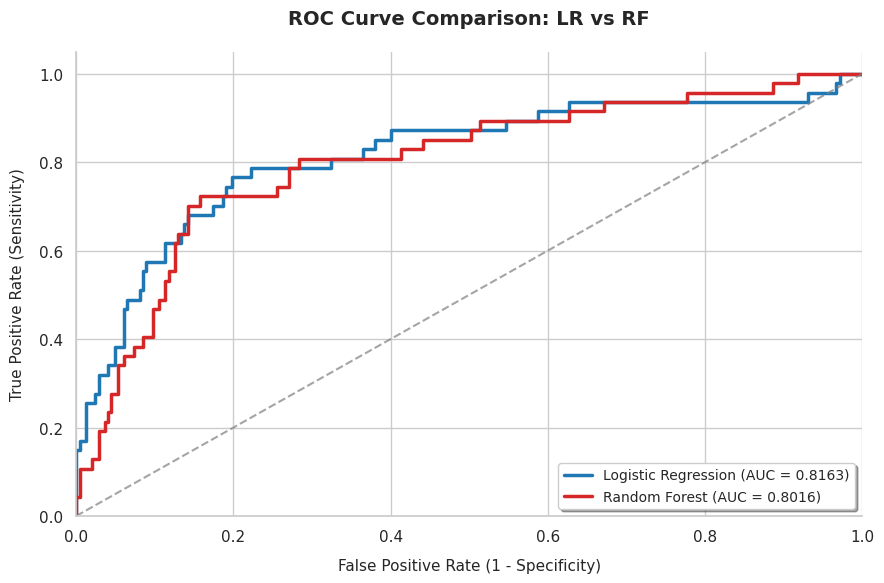

In [51]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 1. 設定 Seaborn 風格與美化參數
sns.set_theme(style="whitegrid")

# 2. 計算 ROC 曲線數據 (LR & RF)
fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 3. 建立繪圖物件，增加 DPI 提高解析度
plt.figure(figsize=(9, 6), dpi=100)

# 4. 使用 Seaborn 色彩調性繪製曲線
plt.plot(fpr_lr, tpr_lr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, color='#d62728', lw=2.5, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

# 5. 繪製隨機參考線 (50/50 猜測)
plt.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.5, linestyle='--', alpha=0.7)

# 6. 細節優化：座標軸範圍、標籤、標題與圖例
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11, labelpad=10)
plt.title('ROC Curve Comparison: LR vs RF', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", frameon=True, fontsize=10, shadow=True)

# 7. 移除不必要的邊框 (減少視覺噪音)
sns.despine()

plt.tight_layout()
plt.show()

### 3.2 混淆矩陣可視化比較
使用 `Seaborn` 的熱圖來繪製兩個模型的混淆矩陣，並將標籤設為 True/False 以對應離職（Attrition）的分類。

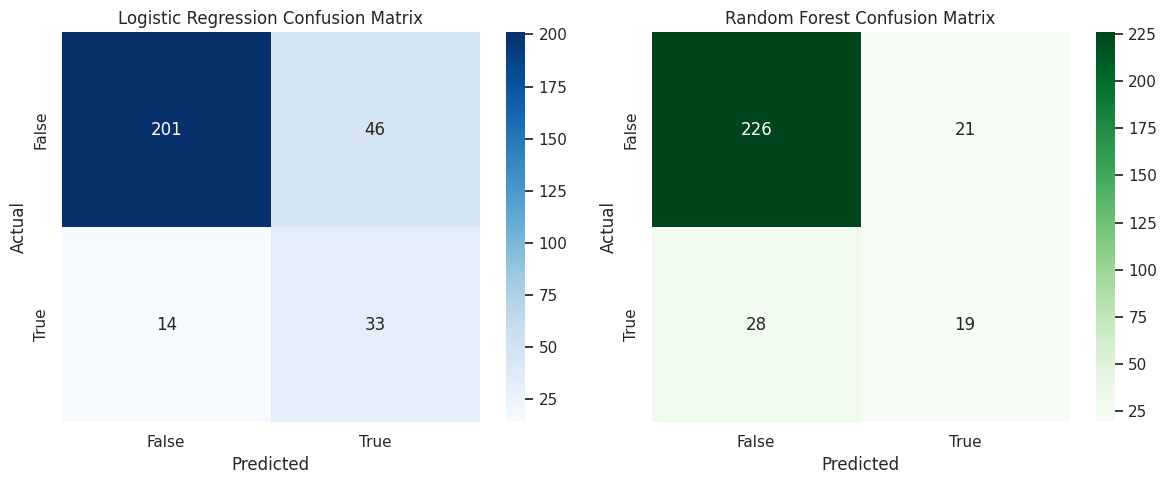

In [52]:
import seaborn as sns

def plot_cm_comparison(y_true_lr,y_true_rf, y_pred_lr, y_pred_rf):
    cm_lr = confusion_matrix(y_true_lr, y_pred_lr)
    cm_rf = confusion_matrix(y_true_rf, y_pred_rf)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Logistic Regression CM
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['False', 'True'], yticklabels=['False', 'True'])
    ax[0].set_title('Logistic Regression Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # Random Forest CM
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax[1],
                xticklabels=['False', 'True'], yticklabels=['False', 'True'])
    ax[1].set_title('Random Forest Confusion Matrix')
    ax[1].set_xlabel('Predicted')
    ax[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

plot_cm_comparison(y_test_lr,y_test_rf, y_pred_lr, y_pred_rf)

### 3.3 特徵相關性分析 (Correlation Heatmap)

計算所有特徵與目標變數 `Attrition` 的相關性，並由高到低排序，以熱圖呈現哪些因素最直接影響離職。

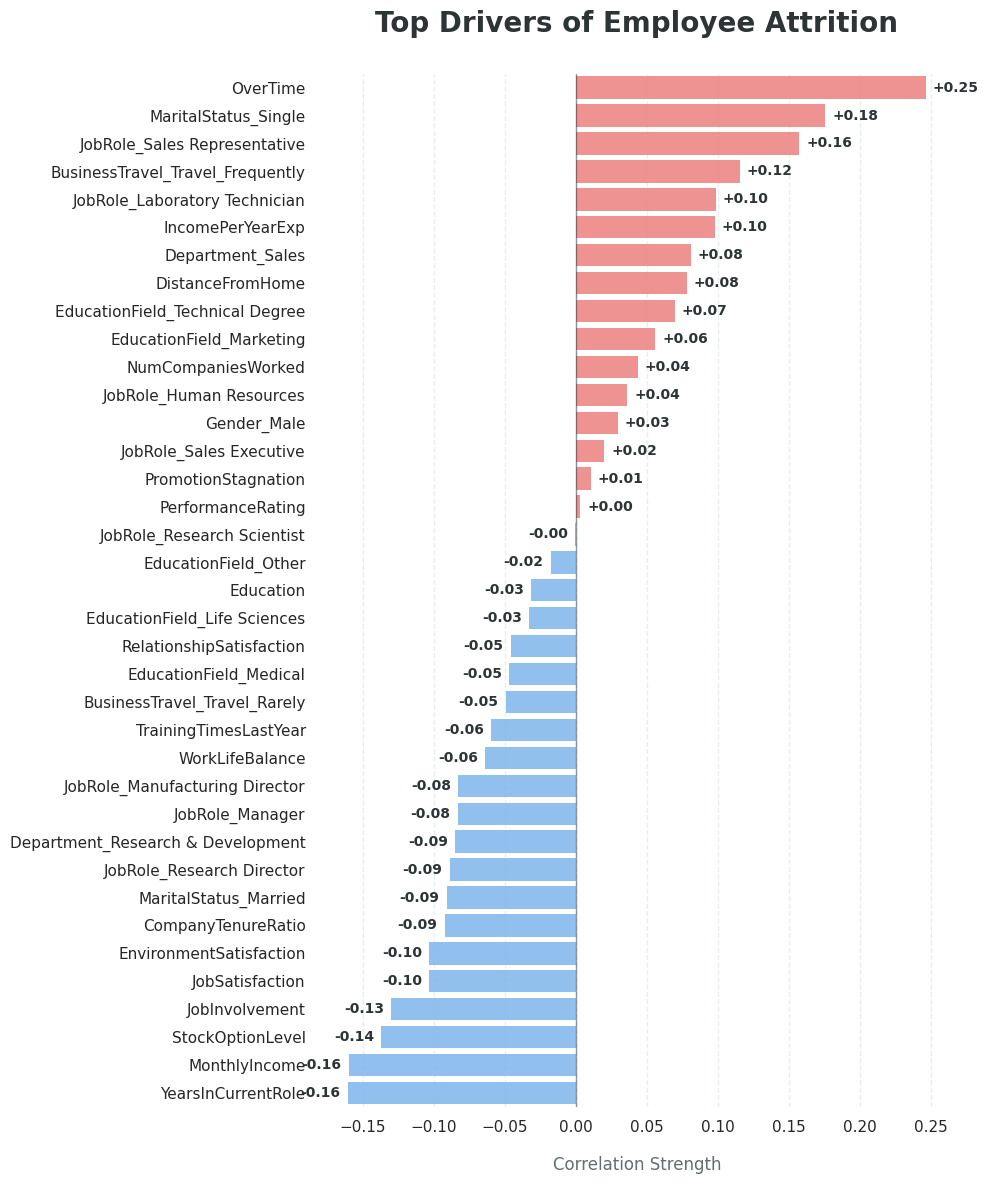

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 數據準備
correlations = df.corr()['Attrition'].sort_values(ascending=False).drop('Attrition')

# 2. 設定極致簡約美學風格
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 12), dpi=100)

# 3. 使用較柔和但具對比性的專業配色 (Soft Red & Blue)
colors = ['#ff7675' if x > 0 else '#74b9ff' for x in correlations.values]

# 4. 繪製條形圖
sns.barplot(
    x=correlations.values,
    y=correlations.index,
    palette=colors,
    edgecolor='none', # 移除邊框更顯現代感
    alpha=0.9,
    ax=ax
)

# 5. 精緻化排版與裝飾
ax.axvline(x=0, color='#2d3436', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('Top Drivers of Employee Attrition', fontsize=20, fontweight='bold', pad=30, color='#2d3436')
ax.set_xlabel('Correlation Strength', fontsize=12, labelpad=15, color='#636e72')
ax.set_ylabel('', fontsize=12)

# 優化網格：只保留垂直的淡灰色網格
ax.xaxis.grid(True, linestyle='--', which='major', color='#dfe6e9', alpha=0.7)
ax.set_axisbelow(True)

# 添加數值標籤，改用更簡潔的呈現方式
for i, v in enumerate(correlations.values):
    ha = 'left' if v > 0 else 'right'
    offset = 0.005 if v > 0 else -0.005
    ax.text(v + offset, i, f'{v:+.2f}',
            va='center', ha=ha, fontsize=10,
            fontweight='bold', color='#2d3436')

# 移除多餘的刻度線與邊框
sns.despine(left=True, bottom=True)
plt.tick_params(axis='both', which='both', bottom=False, left=False)

plt.tight_layout()
plt.show()

#### 4.1 先分別打包Model和scaler

In [54]:
#打包訓練好的模型&正規化轉換模組
import joblib
joblib.dump(automl_lr, 'model_lr.pkl')
joblib.dump(automl_rf, 'model_rf.pkl')
joblib.dump(scale_standard, 'scale_standard.pkl')

['scale_standard.pkl']

Top 30 Features by Importance:
                             Feature  Importance
5                      MonthlyIncome    0.155840
15                  IncomePerYearExp    0.075321
16                CompanyTenureRatio    0.074409
7                           OverTime    0.069639
13                YearsInCurrentRole    0.054142
0                   DistanceFromHome    0.052571
10                  StockOptionLevel    0.049326
14               PromotionStagnation    0.044313
6                 NumCompaniesWorked    0.041382
2            EnvironmentSatisfaction    0.036629
4                    JobSatisfaction    0.031326
3                     JobInvolvement    0.028102
12                   WorkLifeBalance    0.025787
9           RelationshipSatisfaction    0.024275
1                          Education    0.023715
36              MaritalStatus_Single    0.021931
11             TrainingTimesLastYear    0.019670
28     JobRole_Laboratory Technician    0.017812
17  BusinessTravel_Travel_Frequently  

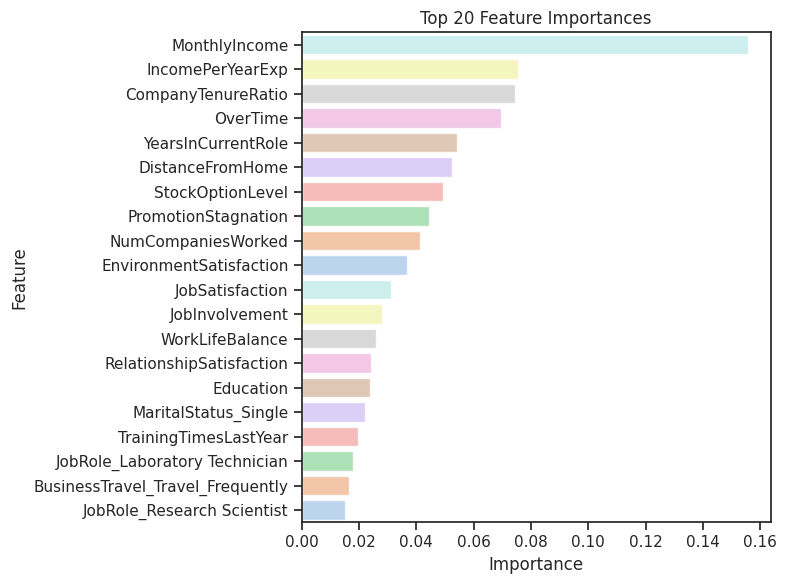

In [55]:
#重新讀取訓練好的模型
import joblib
import seaborn as sns
import matplotlib.pyplot as plt


model_lr = joblib.load('model_lr.pkl')
model_rf = joblib.load('model_rf.pkl')
#哪些是重要特徵
importances= model_rf.feature_importances_
feature_names= df.columns[df.columns!='Attrition']
# Create a DataFrame for importances
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)


# Print top 20 features
print("Top 30 Features by Importance:")
print(importance_df.head(20))

# Check for hierarchy
top_importance_sum = importance_df['Importance'].head(20).sum()
print(f"\nSum of importances for top 20 features: {top_importance_sum:.4f}")
print(f"Max importance: {importance_df['Importance'].max():.4f}")
print(f"Median importance: {importance_df['Importance'].median():.4f}")

# Plotting
sns.set_theme(style="ticks")
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='pastel', hue='Importance',alpha=0.8, legend=False)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("\nSaved feature importance plot to feature_importance.png")

In [56]:
import pandas as pd

# 從 FLAML 物件中取得最佳的 Logistic Regression 模型
best_lr_model = model_lr.model.estimator

# 取得係數 (coefficients)
coefficients = best_lr_model.coef_[0]

# 取得特徵名稱
feature_names = df.columns[df.columns != 'Attrition']

# 建立 DataFrame 並排序
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("Logistic Regression Feature Coefficients:")
display(coef_df)



Logistic Regression Feature Coefficients:


,Feature,Coefficient
7,OverTime,0.696010
17,BusinessTravel_Travel_Frequently,0.639061
28,JobRole_Laboratory Technician,0.558249
15,IncomePerYearExp,0.430174
6,NumCompaniesWorked,0.418566
18,BusinessTravel_Travel_Rarely,0.417570
2,EnvironmentSatisfaction,-0.397119
34,JobRole_Sales Representative,0.387692
36,MaritalStatus_Single,0.372390
4,JobSatisfaction,-0.343487


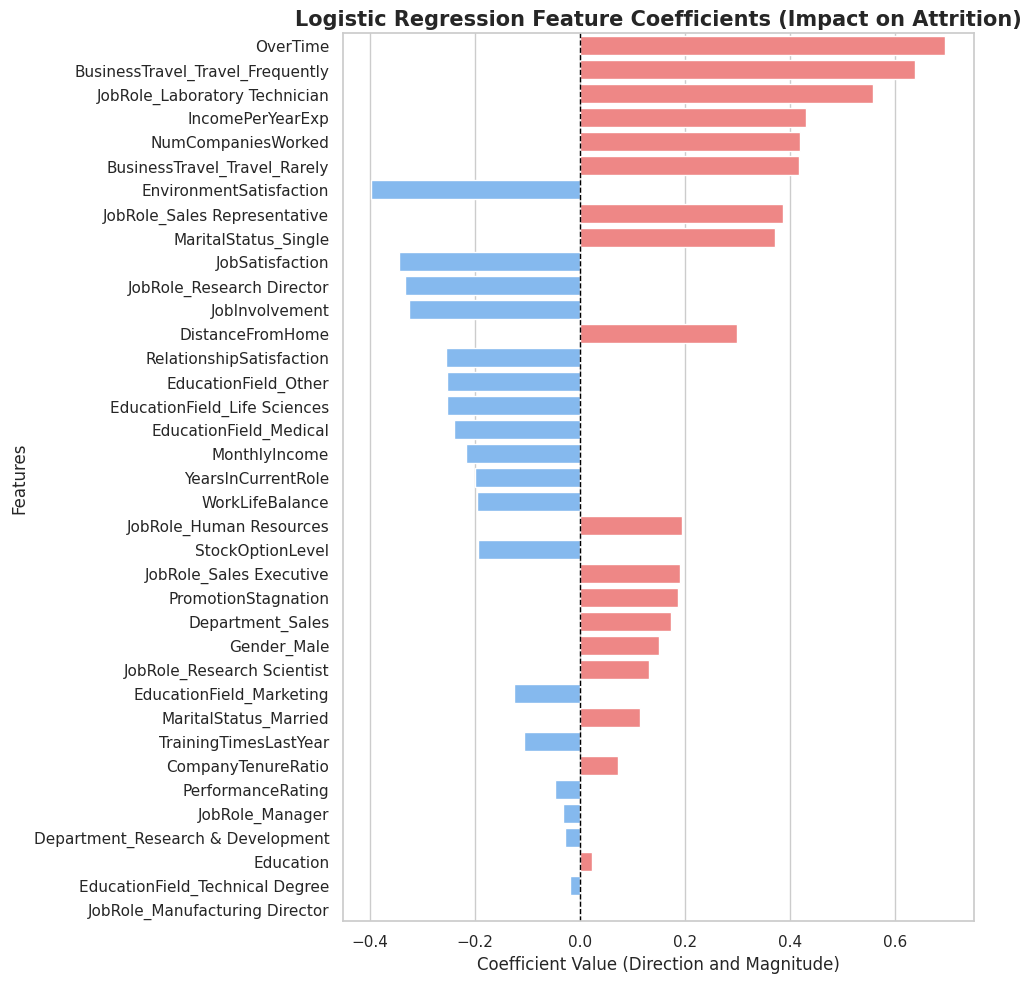

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定繪圖風格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 10))

# 繪製長條圖
# 根據係數正負給予不同顏色
colors = ['#ff7675' if x > 0 else '#74b9ff' for x in coef_df['Coefficient']]

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coef_df,
    palette=colors,
    hue='Feature',
    legend=False
)

plt.title('Logistic Regression Feature Coefficients (Impact on Attrition)', fontsize=15, fontweight='bold')
plt.xlabel('Coefficient Value (Direction and Magnitude)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# 加入垂直線標示 0
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### 4. 如何預設結果，以員工預測值為例

In [58]:
try:
    # 1. 將 X_default 進行標準化轉換 (使用先前訓練時定義的 scale_standard)
    # 注意：轉換後會變成 ndarray
    X_default_scaled = scale_standard.transform(X_default)

    # 2. 直接使用底層 estimator 進行預測，避開 DataTransformer 的狀態問題
    best_lr_estimator = model_lr.model.estimator

    prediction = best_lr_estimator.predict(X_default_scaled)
    prediction_proba = best_lr_estimator.predict_proba(X_default_scaled)[:, 1]

    print(f"預測結果 (Attrition): {'是 (1)' if prediction[0] == 1 else '否 (0)'}")
    print(f"離職機率: {prediction_proba[0]:.4f}")

except Exception as e:
    print(f"預測時發生錯誤: {e}")
    print("提示：若錯誤持續，請檢查 X_default 欄位順序是否與訓練時的 X 相同。")

預測結果 (Attrition): 否 (0)
離職機率: 0.0729


In [76]:
# 1. 重新初始化 X_default 確保基準值正確
X_default = df.drop(columns=['Attrition'])[:1].copy()
bool_cols = df.select_dtypes(include=['bool']).columns
for col in X_default.columns:
    if col not in bool_cols:
        X_default[col] = int(df[col].median())
    else:
        X_default[col] = int(df[col].mode()[0])

# 2. 定義預測與檢查函數
def print_prediction_v3(model, X_df, label=""):
    print(f"--- {label} ---")
    print(f"實際測試數值 -> OverTime: {X_df['OverTime'].values[0]}, MonthlyIncome: {X_df['MonthlyIncome'].values[0]}")

    X_scaled = scale_standard.transform(X_df)
    prediction = model.predict(X_scaled)
    prediction_proba = model.predict_proba(X_scaled)[:, 1]

    print(f"離職機率: {prediction_proba[0]:.4f}")
    print(f"預測結果 (Attrition): {'是 (1)' if prediction[0] == 1 else '否 (0)'}\n")

# 3. 進行對比測試
# 0. 正確的預設基準值
print_prediction_v3(model_lr, X_default.copy(), "0. 原始預設基準值")

# 1. 測試加班影響
X_test_ot = X_default.copy()
X_test_ot['OverTime'] = 1
print_prediction_v3(model_lr, X_test_ot, "1. 單獨將 OverTime 改為 1 (加班)")

# 2. 測試薪水影響 (改為極低)
X_test_low_income = X_default.copy()
X_test_low_income['MonthlyIncome'] = 1000
print_prediction_v3(model_lr, X_test_low_income, "2. 單獨將 MonthlyIncome 改為 1000 (低薪)")

# 3. 測試加乘影響
X_test_both = X_default.copy()
X_test_both['OverTime'] = 1
X_test_both['MonthlyIncome'] = 1000
print_prediction_v3(model_lr, X_test_both, "3. 同時加班且低薪")

# 4. 測試調高sotckoption level的影響
X_test_high_stock = X_default.copy()
X_test_high_stock['StockOptionLevel'] = 4
print_prediction_v3(model_lr, X_test_high_stock, "4. 單獨調高 StockOptionLevel")

# 5. 測試調高薪水但加班的影響
X_test_high_income_ot = X_default.copy()
X_test_high_income_ot['OverTime'] = 1
X_test_high_income_ot['MonthlyIncome'] = 20000
print_prediction_v3(model_lr, X_test_high_income_ot, "5. 加班且調高薪水")
# 6. 測試調高薪水到10000但加班的影響
X_test_high_income_ot = X_default.copy()
X_test_high_income_ot['OverTime'] = 1
X_test_high_income_ot['MonthlyIncome'] = 10000
print_prediction_v3(model_lr, X_test_high_income_ot, "6. 加班且調高薪水到10000")

#.7.測試加班和薪水調低到3000
X_test_low_income_ot = X_default.copy()
X_test_low_income_ot['OverTime'] = 1
X_test_low_income_ot['MonthlyIncome'] = 3000
print_prediction_v3(model_lr, X_test_low_income_ot, "7. 加班且調低薪水到3000")

#.8.測試加班和薪水調低到2000
X_test_low_income_ot = X_default.copy()
X_test_low_income_ot['OverTime'] = 1
X_test_low_income_ot['MonthlyIncome'] = 2000
print_prediction_v3(model_lr, X_test_low_income_ot, "8. 加班且調低薪水到2000")
#.9. 測試加班、薪水條低到3000、常常出差
X_test_low_income_ot = X_default.copy()
X_test_low_income_ot['OverTime'] = 1
X_test_low_income_ot['MonthlyIncome'] = 10000
X_test_low_income_ot['BusinessTravel_Travel_Frequently'] = 1
print_prediction_v3(model_lr, X_test_low_income_ot, "9. 加班、調低薪水到3000、常常出差")
#.10. 測試加班、薪資/年資

--- 0. 原始預設基準值 ---
實際測試數值 -> OverTime: 0, MonthlyIncome: 4919
離職機率: 0.0729
預測結果 (Attrition): 否 (0)

--- 1. 單獨將 OverTime 改為 1 (加班) ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 4919
離職機率: 0.2694
預測結果 (Attrition): 否 (0)

--- 2. 單獨將 MonthlyIncome 改為 1000 (低薪) ---
實際測試數值 -> OverTime: 0, MonthlyIncome: 1000
離職機率: 0.0860
預測結果 (Attrition): 否 (0)

--- 3. 同時加班且低薪 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 1000
離職機率: 0.3062
預測結果 (Attrition): 否 (0)

--- 4. 單獨調高 StockOptionLevel ---
實際測試數值 -> OverTime: 0, MonthlyIncome: 4919
離職機率: 0.0383
預測結果 (Attrition): 否 (0)

--- 5. 加班且調高薪水 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 20000
離職機率: 0.1558
預測結果 (Attrition): 否 (0)

--- 6. 加班且調高薪水到10000 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 10000
離職機率: 0.2260
預測結果 (Attrition): 否 (0)

--- 7. 加班且調低薪水到3000 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 3000
離職機率: 0.2870
預測結果 (Attrition): 否 (0)

--- 8. 加班且調低薪水到2000 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 2000
離職機率: 0.2965
預測結果 (Attrition): 否 (0)

--- 9. 加班、調低薪水到3000、常常出差 ---
實

### 5.因為資料有正規化，使用pipeline方式重新打包模型和scaler

In [66]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#1.重新讀取資料
df_export=pd.read_csv('final_HR-Employee-Attrition.csv')

#2. .確保目標變數 (Y) 轉換為數值 0 和 1 (True->1, False->0)
df_export['Attrition'] = df_export['Attrition'].astype(int)

#2. 將布林形態特徵也都轉為(0/1)
# 假設 df 中有數個布林欄位
bool_cols = df_export.select_dtypes(include=['bool']).columns
# 直接將這些欄位轉成整數 0/1
df_export[bool_cols] = df_export[bool_cols].astype(int)

X_ex = df_export.drop(columns=['Attrition'])
y_ex = df_export['Attrition']
# 建立管線：先做標準化，再進Logistic Regression輸入剛剛AutoML得到的參數
hr_pipeline = Pipeline([('scaler', StandardScaler()),('classifier', LogisticRegression(C=np.float64(0.1620472422498409), class_weight='balanced', n_jobs=-1))])

'''hr_pipeline = Pipeline([
    ('scaler', StandardScaler()),                       # 步驟一：正規化
    ('rf_model', RandomForestClassifier(class_weight='balanced', criterion=np.str_('gini'),
                       max_features=np.float64(0.11521065872523453),
                       max_leaf_nodes=12, n_estimators=147, n_jobs=-1,
                       random_state=12032022)) # 步驟二：模型
])'''
# 1. 切分訓練集與測試集
X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# 餵入「原始」訓練資料，Pipeline 會自動幫 Scaler 做 fit_transform，並餵給 RF
hr_pipeline.fit(X_train_ex, y_train_ex)

# 打包整個 Pipeline 物件
joblib.dump(hr_pipeline, 'hr_attrition_pipeline.pkl')
print("🎉 包含正規化的完整 Pipeline 已成功打包！")

🎉 包含正規化的完整 Pipeline 已成功打包！


In [67]:
#輸出模型欄位順序做確認
import json

# 確保fit 模型的那個 DataFrame 欄位
trained_features = list(X_ex.columns)

with open('trained_features_order.json', 'w') as f:
    json.dump(trained_features, f)

In [68]:
trained_features

['DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobSatisfaction',
 'MonthlyIncome',
 'NumCompaniesWorked',
 'OverTime',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsInCurrentRole',
 'PromotionStagnation',
 'IncomePerYearExp',
 'CompanyTenureRatio',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Male',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',
 'MaritalStatus_Married',
 'MaritalStatus_Single']

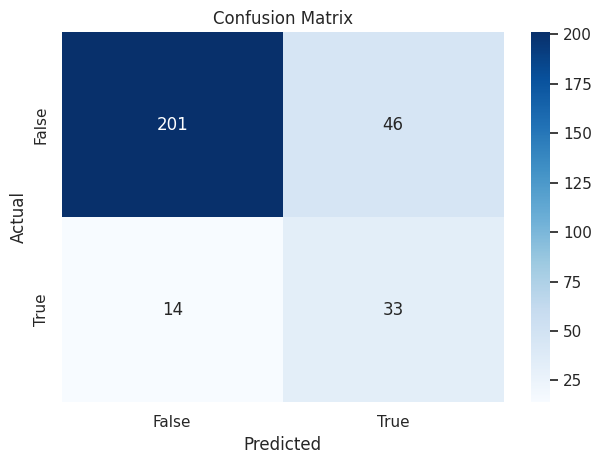

In [69]:
#繪製混淆舉證，再次確認hr_pipeline方式建立出來模型的效力
y_val_pred=hr_pipeline.predict(X_test_ex)
cm=confusion_matrix(y_test_ex,y_val_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()


目前使用的門檻值: 0.5
預測為離職 (True) 的人數: 79
預測為留任 (False) 的人數: 215


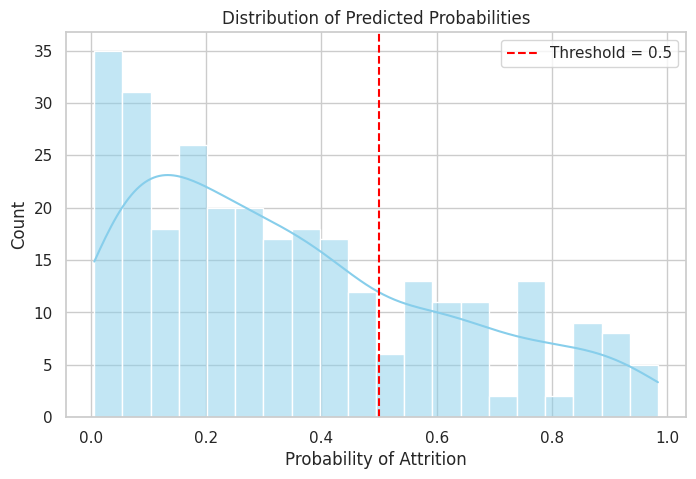

In [70]:
# 取得預測機率 (Attrition = True 的機率)
y_val_proba = hr_pipeline.predict_proba(X_test_ex)[:, 1]

# 設定不同的門檻值來觀察結果
threshold = 0.5  # 這是您目前 predict() 預設使用的值
y_pred_custom = (y_val_proba >= threshold).astype(int)

print(f"目前使用的門檻值: {threshold}")
print(f"預測為離職 (True) 的人數: {sum(y_pred_custom)}")
print(f"預測為留任 (False) 的人數: {len(y_pred_custom) - sum(y_pred_custom)}")

# 繪製機率分佈圖，看看 0.5 切在哪裡
plt.figure(figsize=(8, 5))
sns.histplot(y_val_proba, bins=20, kde=True, color='skyblue')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Probability of Attrition')
plt.ylabel('Count')
plt.legend()
plt.show()

In [82]:
#重新用hr_pipeline連檢驗參數對預測結果的影響

# 2. 定義預測與檢查函數
def print_prediction_v3(model, X_df, label=""):
    print(f"--- {label} ---")
    print(f"實際測試數值 -> OverTime: {X_df['OverTime'].values[0]}, MonthlyIncome: {X_df['MonthlyIncome'].values[0]}")

    X_scaled = scale_standard.transform(X_df)
    prediction = model.predict(X_scaled)
    prediction_proba = model.predict_proba(X_scaled)[:, 1]

    print(f"離職機率: {prediction_proba[0]:.4f}")
    print(f"預測結果 (Attrition): {'是 (1)' if prediction[0] == 1 else '否 (0)'}\n")

# 3. 進行對比測試
# 0. 正確的預設基準值
print_prediction_v3(hr_pipeline, X_default.copy(), "0. 原始預設基準值")

# 1. 測試加班影響
X_test_ot = X_default.copy()
X_test_ot['OverTime'] = 1
print_prediction_v3(hr_pipeline, X_test_ot, "1. 單獨將 OverTime 改為 1 (加班)")

# 2. 測試薪水影響 (改為極低)
X_test_low_income = X_default.copy()
X_test_low_income['MonthlyIncome'] = 1000
print_prediction_v3(hr_pipeline, X_test_low_income, "2. 單獨將 MonthlyIncome 改為 1000 (低薪)")

# 3. 測試加乘影響
X_test_both = X_default.copy()
X_test_both['OverTime'] = 1
X_test_both['MonthlyIncome'] = 1000
print_prediction_v3(hr_pipeline, X_test_both, "3. 同時加班且低薪")

# 4. 測試調高sotckoption level的影響
X_test_high_stock = X_default.copy()
X_test_high_stock['StockOptionLevel'] = 4
print_prediction_v3(hr_pipeline, X_test_high_stock, "4. 單獨調高 StockOptionLevel")

# 5. 測試調高薪水但加班的影響
X_test_high_income_ot = X_default.copy()
X_test_high_income_ot['OverTime'] = 1
X_test_high_income_ot['MonthlyIncome'] = 20000
print_prediction_v3(hr_pipeline, X_test_high_income_ot, "5. 加班且調高薪水")
# 6. 測試調高薪水到10000但加班的影響
X_test_high_income_ot = X_default.copy()
X_test_high_income_ot['OverTime'] = 1
X_test_high_income_ot['MonthlyIncome'] = 10000
print_prediction_v3(hr_pipeline, X_test_high_income_ot, "6. 加班且調高薪水到10000")

#.7.測試加班和薪水調低到3000
X_test_low_income_ot = X_default.copy()
X_test_low_income_ot['OverTime'] = 1
X_test_low_income_ot['MonthlyIncome'] = 3000
print_prediction_v3(hr_pipeline, X_test_low_income_ot, "7. 加班且調低薪水到3000")

#.8.測試加班和薪水調低到2000
X_test_low_income_ot = X_default.copy()
X_test_low_income_ot['OverTime'] = 1
X_test_low_income_ot['MonthlyIncome'] = 2000
print_prediction_v3(hr_pipeline, X_test_low_income_ot, "8. 加班且調低薪水到2000")
# 9.測試加班、頻繁出差、薪資的影響
X_test_low_income_ot_travel = X_default.copy()
X_test_low_income_ot_travel['OverTime'] = 1
X_test_low_income_ot_travel['MonthlyIncome'] = 10000
X_test_low_income_ot_travel['BusinessTravel_Travel_Frequently']=1
print_prediction_v3(hr_pipeline,X_test_low_income_ot_travel,"9. 加班、出差、薪水：10000")

#10. 測試加班、頻繁出差、薪水20000
X_test_low_income_ot_travel = X_default.copy()
X_test_low_income_ot_travel['OverTime'] = 1
X_test_low_income_ot_travel['MonthlyIncome'] = 20000
X_test_low_income_ot_travel['BusinessTravel_Travel_Frequently']=1
print_prediction_v3(hr_pipeline,X_test_low_income_ot_travel,"10. 加班、出差、薪水：20000")
#11.測試薪資/平均年資, 加班
X_test_ICPY = X_default.copy()
X_test_ICPY['OverTime']=1
X_test_ICPY['IncomePerYearExp']=587.0
print_prediction_v3(hr_pipeline,X_test_ICPY,"11. 加班、薪資/年資:587(平均值)")

#12.測試薪資/平均年資, 加班
X_test_ICPY = X_default.copy()
X_test_ICPY['OverTime']=1
X_test_ICPY['IncomePerYearExp']=100.0
print_prediction_v3(hr_pipeline,X_test_ICPY,"11. 加班、薪資/年資:100(超低值)")




--- 0. 原始預設基準值 ---
實際測試數值 -> OverTime: 0, MonthlyIncome: 4919
離職機率: 0.0732
預測結果 (Attrition): 否 (0)

--- 1. 單獨將 OverTime 改為 1 (加班) ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 4919
離職機率: 0.2700
預測結果 (Attrition): 否 (0)

--- 2. 單獨將 MonthlyIncome 改為 1000 (低薪) ---
實際測試數值 -> OverTime: 0, MonthlyIncome: 1000
離職機率: 0.0863
預測結果 (Attrition): 否 (0)

--- 3. 同時加班且低薪 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 1000
離職機率: 0.3068
預測結果 (Attrition): 否 (0)

--- 4. 單獨調高 StockOptionLevel ---
實際測試數值 -> OverTime: 0, MonthlyIncome: 4919
離職機率: 0.0384
預測結果 (Attrition): 否 (0)

--- 5. 加班且調高薪水 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 20000
離職機率: 0.1563
預測結果 (Attrition): 否 (0)

--- 6. 加班且調高薪水到10000 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 10000
離職機率: 0.2266
預測結果 (Attrition): 否 (0)

--- 7. 加班且調低薪水到3000 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 3000
離職機率: 0.2877
預測結果 (Attrition): 否 (0)

--- 8. 加班且調低薪水到2000 ---
實際測試數值 -> OverTime: 1, MonthlyIncome: 2000
離職機率: 0.2972
預測結果 (Attrition): 否 (0)

--- 9. 加班、出差、薪水：10000 ---
實際測試